In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect

import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle





In [2]:
file = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Oral toxicity\dataset\train_set_acute_oral_features_rdkitcdk.sdf"

sdfInfo = dict(smilesName='SMILES',molColName='ROMol')
moldf = PandasTools.LoadSDF(file,**sdfInfo)
print(moldf.shape)
moldf = moldf.rename(columns={'ROMol': 'Mol'})
moldf = moldf.drop_duplicates(subset=['SMILES'])
moldf = moldf[pd.notnull(moldf['Mol'])]
print(moldf.shape)
moldf.keys()

[11:58:15] Explicit valence for atom # 1 Si, 5, is greater than permitted
[11:58:15] ERROR: Could not sanitize molecule ending on line 1262186
[11:58:15] ERROR: Explicit valence for atom # 1 Si, 5, is greater than permitted


(6566, 80)
(6566, 80)


Index(['CASRN', 'DTXSID', 'Name', 'Structure_Source', 'Canonical_QSARr',
       'Salt_Solvent', 'InChI_Code_QSARr', 'InChI Key_QSARr', 'very_toxic',
       'nontoxic', 'StandardizerResult', 'Outcome', 'ID', 'GHS_category',
       'EPA_category', 'LD50_mgkg', 'RowID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'SMILES', 'Molecular Weight',
       'logP', 'LabuteASA', 'TPSA', 'AMW', 'NumLipinskiHBA', 'NumLipinskiHBD',
       'NumRotatableBonds', 'NumHBD', 'NumHBA', 'NumAmideBonds',
       'NumHeteroAtoms', 'NumAtoms', 'NumRings', 'NumAromaticRings',
       'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'FractionCSP3', 'Chi0v', 'Chi1v', 'Chi2v',
       'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha',
       'kappa1', 'kappa2', 'kappa3', 'ALogP', 'ALogP2', 'AMR', '

In [3]:
moldf

,CASRN,DTXSID,Name,Structure_Source,Canonical_QSARr,Salt_Solvent,InChI_Code_QSARr,InChI Key_QSARr,very_toxic,nontoxic,...,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Mol
0,62899-75-6,nan,,Public_CrossChecked,CCN(C1CCCCC1)C(=O)Cl,?,InChI=1S/C9H16ClNO/c1-2-11(9(10)12)8-6-4-3-5-7...,ONKIPJDBUYZQMP-UHFFFAOYSA-N,FALSE,FALSE,...,2.0,5.0,0.5,3.0,0.0,20.31,4.584962500721156,2.499,0.8888888888888888,<rdkit.Chem.rdchem.Mol object at 0x0000011D842...
1,15351-05-0,nan,,Public_CrossChecked,C[N+]1(CCC(C(N)=O)(C2C=CC=CC=2)C2C=CC=CC=2)CCC...,[I-],InChI=1S/C23H30N2O/c1-25(17-10-2-3-11-18-25)19...,HDGFUOKLIQJQCS-UHFFFAOYSA-O,FALSE,TRUE,...,4.0,5.0,0.5,6.0,0.0,43.09,5.807354922057604,3.917,0.4347826086956521,<rdkit.Chem.rdchem.Mol object at 0x0000011D842...
2,633-99-8,DTXSID50212691,1-Chloro-2-naphthol,EPA_DSSTox,OC1C=CC2=CC=CC=C2C=1Cl,?,InChI=1S/C10H7ClO/c11-10-8-4-2-1-3-7(8)5-6-9(1...,RMSOEGBYNWXXBG-UHFFFAOYSA-N,FALSE,TRUE,...,0.0,0.0,0.5,0.0,0.0,20.23,4.700439718141093,3.504,0.0,<rdkit.Chem.rdchem.Mol object at 0x0000011D842...
3,68955-20-4,DTXSID8029523,"Sulfuric acid, mono-C16-18-alkyl esters, sodiu...",EPA_DSSTox,CCCCCCCCCCCCCCCCCOS(O)(=O)=O,[Na+],InChI=1S/C17H36O4S/c1-2-3-4-5-6-7-8-9-10-11-12...,KGIBGHABTNQVJX-UHFFFAOYSA-N,FALSE,FALSE,...,17.0,20.0,0.4736842105263157,17.0,2.0,71.98,5.392317422778761,6.951,1.0,<rdkit.Chem.rdchem.Mol object at 0x0000011D842...
4,84731-70-4,nan,,Public_CrossChecked,CCCCC(COC(=O)C1CCC(CC1)C(=O)OCC(CCCC)CC)CC,?,InChI=1S/C24H44O4/c1-5-9-11-19(7-3)17-27-23(25...,HOQGHOMLEVKTBY-UHFFFAOYSA-N,FALSE,TRUE,...,7.0,9.0,0.4736842105263157,16.0,2.0,52.60000000000001,5.807354922057604,7.602,0.9166666666666666,<rdkit.Chem.rdchem.Mol object at 0x0000011D842...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6562,80464-05-7,nan,,Public_CrossChecked,CN(C)C1C=CC(=CC=1)NC(=O)CCCSC1=NN=NN1C,?,InChI=1S/C14H20N6OS/c1-19(2)12-8-6-11(7-9-12)1...,WKLKPZAMTNLNQV-UHFFFAOYSA-N,FALSE,FALSE,...,6.0,14.0,0.4615384615384615,9.0,0.0,52.60000000000001,4.906890595608519,1.1840000000000002,0.5,<rdkit.Chem.rdchem.Mol object at 0x0000011D98C...
6563,64050-54-0,DTXSID60214181,"1H-Benz(de)isoquinoline-1,3(2H)-dione, 2-((dim...",EPA_DSSTox,COP(=O)(ON1C(=O)C2C=CC=C3C=CC=C(C3=2)C1=O)OC,?,"InChI=1S/C14H12NO6P/c1-19-22(18,20-2)21-15-13(...",SFWMYVAUEVMHSH-UHFFFAOYSA-N,FALSE,FALSE,...,0.0,3.0,0.4615384615384615,5.0,0.0,203.27,6.0,0.2239999999999998,0.0588235294117647,<rdkit.Chem.rdchem.Mol object at 0x0000011D98C...
6564,6900-06-7,DTXSID90219043,"Adipic acid, di-2-propynyl ester",EPA_DSSTox,C#CCOC(=O)CCCCC(=O)OCC#C,?,InChI=1S/C12H14O4/c1-3-9-15-11(13)7-5-6-8-12(1...,UUKXRCZQOHIIPD-UHFFFAOYSA-N,FALSE,FALSE,...,2.0,2.0,0.5,3.0,0.0,41.57000000000001,5.392317422778761,1.929,0.5333333333333333,<rdkit.Chem.rdchem.Mol object at 0x0000011D98C...
6565,6837-93-0,DTXSID00218502,"2,7-Naphthalenedisulfonic acid, 4-amino-5-hydr...",EPA_DSSTox,CC1C=CC(=CC=1)S(=O)(=O)OC1=CC(=CC2=CC(=CC(N)=C...,?,InChI=1S/C17H15NO9S3/c1-10-2-4-12(5-3-10)30(25...,ZIQWUYNDHGXLIN-UHFFFAOYSA-N,FALSE,TRUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<rdkit.Chem.rdchem.Mol object at 0x0000011D98C...


In [4]:
moldf = moldf.rename(columns={'Outcome': 'Outcome'})

moldf.head(1)

,CASRN,DTXSID,Name,Structure_Source,Canonical_QSARr,Salt_Solvent,InChI_Code_QSARr,InChI Key_QSARr,very_toxic,nontoxic,...,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Mol
0,62899-75-6,nan,,Public_CrossChecked,CCN(C1CCCCC1)C(=O)Cl,?,InChI=1S/C9H16ClNO/c1-2-11(9(10)12)8-6-4-3-5-7...,ONKIPJDBUYZQMP-UHFFFAOYSA-N,FALSE,FALSE,...,2.0,5.0,0.5,3.0,0.0,20.31,4.584962500721156,2.499,0.8888888888888888,<rdkit.Chem.rdchem.Mol object at 0x0000011D842...


In [5]:
moldf= moldf.sort_values(['Outcome'], ascending=True)
moldf.head(100)

,CASRN,DTXSID,Name,Structure_Source,Canonical_QSARr,Salt_Solvent,InChI_Code_QSARr,InChI Key_QSARr,very_toxic,nontoxic,...,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Mol
4672,7620-77-1,DTXSID9027655,"Octadecanoic acid, 12-hydroxy-, monolithium salt",EPA_DSSTox,CCCCCCC(O)CCCCCCCCCCC(O)=O,[Li+],InChI=1S/C18H36O3/c1-2-3-4-11-14-17(19)15-12-9...,ULQISTXYYBZJSJ-UHFFFAOYSA-N,FALSE,NA,...,2.0,9.0,0.5,7.0,0.0,105.74,5.321928094887363,4.9060000000000015,0.3333333333333333,<rdkit.Chem.rdchem.Mol object at 0x0000011D92B...
5619,3806-34-6,DTXSID2027549,"2,4,8,10-Tetraoxa-3,9-diphosphaspiro[5.5]undec...",EPA_DSSTox,CCCCCCCCCCCCCCCCCCOP1OCC2(COP(OC2)OCCCCCCCCCCC...,?,InChI=1S/C41H82O6P2/c1-3-5-7-9-11-13-15-17-19-...,PZRWFKGUFWPFID-UHFFFAOYSA-N,FALSE,NA,...,3.0,3.0,0.4444444444444444,4.0,0.0,108.21,5.08746284125034,2.7340000000000004,0.7,<rdkit.Chem.rdchem.Mol object at 0x0000011D953...
142,20769-85-1,DTXSID7045077,2-Bromo-2-methylpropionyl bromide,EPA_DSSTox,CC(C)(Br)C(=O)Br,?,"InChI=1S/C4H6Br2O/c1-4(2,6)3(5)7/h1-2H3",YOCIJWAHRAJQFT-UHFFFAOYSA-N,FALSE,NA,...,3.0,4.0,0.3333333333333333,1.0,0.0,17.07,3.584962500721156,1.826,0.75,<rdkit.Chem.rdchem.Mol object at 0x0000011D843...
5326,3332-27-2,DTXSID2029660,"1-Tetradecanamine, N,N-dimethyl-, N-oxide",EPA_DSSTox,CCCCCCCCCCCCCC[N+](C)(C)[O-],?,InChI=1S/C16H35NO/c1-4-5-6-7-8-9-10-11-12-13-1...,ONHFWHCMZAJCFB-UHFFFAOYSA-N,FALSE,NA,...,0.0,0.0,0.375,0.0,1.0,18.46,5.392317422778761,5.804,0.0,<rdkit.Chem.rdchem.Mol object at 0x0000011D951...
3301,96525-23-4,DTXSID5058228,Flurtamone,EPA_DSSTox,CNC1OC(C(=O)C=1C1C=C(C=CC=1)C(F)(F)F)C1C=CC=CC=1,?,InChI=1S/C18H14F3NO2/c1-22-17-14(12-8-5-9-13(1...,NYRMIJKDBAQCHC-UHFFFAOYSA-N,FALSE,NA,...,0.0,3.0,0.4545454545454545,3.0,0.0,38.66,5.700439718141093,3.71,0.2222222222222222,<rdkit.Chem.rdchem.Mol object at 0x0000011D8DF...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2559,112-48-1,DTXSID5074268,Ethylene glycol dibutyl ether,EPA_DSSTox,CCCCOCCOCCCC,?,InChI=1S/C10H22O2/c1-3-5-7-11-9-10-12-8-6-4-2/...,GDXHBFHOEYVPED-UHFFFAOYSA-N,FALSE,TRUE,...,4.0,12.0,0.4545454545454545,9.0,0.0,18.46,4.459431618637298,2.53,1.0,<rdkit.Chem.rdchem.Mol object at 0x0000011D8B9...
5125,295800-70-3,DTXSID50630134,"1,4-Bis[(2-ethylhexyl)amino]-5,8-dihydroxyanth...",EPA_DSSTox,CCCCC(CNC1=CC=C(NCC(CCCC)CC)C2=C1C(=O)C1C(C2=O...,?,InChI=1S/C30H42N2O4/c1-5-9-11-19(7-3)17-31-21-...,HJPZLFBZKDXVOA-UHFFFAOYSA-N,FALSE,TRUE,...,3.0,8.0,0.4285714285714285,5.0,0.0,91.85,4.584962500721156,-0.2329999999999999,0.5714285714285714,<rdkit.Chem.rdchem.Mol object at 0x0000011D93F...
2561,23288-49-5,DTXSID2045440,Probucol,EPA_DSSTox,CC(C)(SC1=CC(=C(O)C(=C1)C(C)(C)C)C(C)(C)C)SC1=...,?,"InChI=1S/C31H48O2S2/c1-27(2,3)21-15-19(16-22(2...",FYPMFJGVHOHGLL-UHFFFAOYSA-N,FALSE,TRUE,...,3.0,3.0,0.5,8.0,2.0,91.06,6.169925001442312,11.134000000000004,0.6129032258064516,<rdkit.Chem.rdchem.Mol object at 0x0000011D8B9...
2564,95-49-8,DTXSID8023977,2-Chlorotoluene,EPA_DSSTox,CC1=CC=CC=C1Cl,?,"InChI=1S/C7H7Cl/c1-6-4-2-3-5-7(6)8/h2-5H,1H3",IBSQPLPBRSHTTG-UHFFFAOYSA-N,FALSE,TRUE,...,0.0,0.0,0.25,0.0,0.0,0.0,4.0,2.87,0.1428571428571428,<rdkit.Chem.rdchem.Mol object at 0x0000011D8B9...


In [6]:
moldf =moldf.dropna()

In [7]:
moldf = moldf[(moldf['Outcome']== '0')|(moldf['Outcome']== '1')]
moldf= moldf.sort_values(['Outcome'], ascending=True)

moldf

,CASRN,DTXSID,Name,Structure_Source,Canonical_QSARr,Salt_Solvent,InChI_Code_QSARr,InChI Key_QSARr,very_toxic,nontoxic,...,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Mol
2538,220899-03-6,DTXSID9058020,Metrafenone,EPA_DSSTox,CC1C(Br)=CC=C(OC)C=1C(=O)C1=C(OC)C(OC)=C(C=C1C)OC,?,InChI=1S/C19H21BrO5/c1-10-9-14(23-4)18(24-5)19...,AMSPWOYQQAWRRM-UHFFFAOYSA-N,FALSE,TRUE,...,0.0,2.0,0.5,6.0,0.0,53.99000000000001,5.700439718141093,4.429,0.3157894736842105,<rdkit.Chem.rdchem.Mol object at 0x0000011D8B9...
1172,88-24-4,DTXSID7038864,"2,2'-Methylenebis(ethyl-6-tert-butylphenol)",EPA_DSSTox,CC(C)(C)C1=CC(CC)=CC(CC2C=C(CC)C=C(C=2O)C(C)(C...,?,InChI=1S/C25H36O2/c1-9-16-11-18(22(26)20(13-16...,GPNYZBKIGXGYNU-UHFFFAOYSA-N,FALSE,TRUE,...,3.0,3.0,0.5,6.0,1.0,40.46,5.807354922057604,7.979000000000003,0.52,<rdkit.Chem.rdchem.Mol object at 0x0000011D87C...
5916,82875-39-6,DTXSID60232047,"5-Thiazolecarboxamide, 2-(3,4-dimethoxyphenyl)...",EPA_DSSTox,CC1N=C(SC=1C(=O)NC)C1C=C(OC)C(=CC=1)OC,?,InChI=1S/C14H16N2O3S/c1-8-12(13(17)15-2)20-14(...,QNIHAJJHPNMVJY-UHFFFAOYSA-N,FALSE,TRUE,...,0.0,0.0,0.25,0.0,0.0,26.02,4.700439718141093,2.312,1.0,<rdkit.Chem.rdchem.Mol object at 0x0000011D966...
1176,109-78-4,DTXSID1025433,3-Hydroxypropanenitrile,EPA_DSSTox,N#CCCO,?,"InChI=1S/C3H5NO/c4-2-1-3-5/h5H,1,3H2",WSGYTJNNHPZFKR-UHFFFAOYSA-N,FALSE,TRUE,...,3.0,5.0,0.5,1.0,0.0,44.02,3.0,-0.848,0.6666666666666666,<rdkit.Chem.rdchem.Mol object at 0x0000011D87C...
1153,42399-49-5,DTXSID6057744,"(2S,3s)-3-hydroxy-2-(4-methoxyphenyl)-2,3-dihy...",EPA_DSSTox,COC1=CC=C(C=C1)C1SC2C=CC=CC=2NC(=O)C1O,?,InChI=1S/C16H15NO3S/c1-20-11-8-6-10(7-9-11)15-...,LHBHZALHFIQJGJ-UHFFFAOYSA-N,FALSE,TRUE,...,0.0,2.0,0.4545454545454545,2.0,0.0,83.86,5.523561956057013,2.9620000000000006,0.1875,<rdkit.Chem.rdchem.Mol object at 0x0000011D87C...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6093,143692-53-9,nan,,Public_CrossChecked,CC1CC2C=C3OCOC3=CC=2C(=NN1C(C)=O)C1C=CC(=CC=1)...,?,InChI=1S/C21H21N3O4/c1-12-8-16-9-19-20(28-11-2...,RNJAHAXIBIIAHU-UHFFFAOYSA-N,FALSE,FALSE,...,0.0,3.0,0.5,5.0,1.0,88.28999999999999,5.523561956057013,7.569,0.0625,<rdkit.Chem.rdchem.Mol object at 0x0000011D968...
6092,1492-02-0,DTXSID6023103,Glybuzole,EPA_DSSTox,CC(C)(C)C1=NN=C(NS(=O)(=O)C2C=CC=CC=2)S1,?,"InChI=1S/C12H15N3O2S2/c1-12(2,3)10-13-14-11(18...",NMWQEPCLNXHPDX-UHFFFAOYSA-N,FALSE,FALSE,...,7.0,7.0,0.4705882352941176,7.0,1.0,76.57000000000001,6.129283016944966,10.554000000000004,1.0,<rdkit.Chem.rdchem.Mol object at 0x0000011D968...
4937,94125-34-5,DTXSID9034868,Prosulfuron,EPA_DSSTox,CC1N=C(NC(=O)NS(=O)(=O)C2=CC=CC=C2CCC(F)(F)F)N...,?,InChI=1S/C15H16F3N5O4S/c1-9-19-12(22-14(20-9)2...,LTUNNEGNEKBSEH-UHFFFAOYSA-N,FALSE,FALSE,...,0.0,5.0,0.5,2.0,0.0,33.36,4.0,-0.281,1.0,<rdkit.Chem.rdchem.Mol object at 0x0000011D93D...
4939,115-26-4,DTXSID8041870,Dimefox,EPA_DSSTox,CN(C)P(=O)(F)N(C)C,?,"InChI=1S/C4H12FN2OP/c1-6(2)9(5,8)7(3)4/h1-4H3",PGJBQBDNXAZHBP-UHFFFAOYSA-N,TRUE,FALSE,...,3.0,4.0,0.4285714285714285,3.0,0.0,35.25,4.700439718141093,2.0729999999999995,0.4545454545454545,<rdkit.Chem.rdchem.Mol object at 0x0000011D93D...


In [8]:
x_data = moldf.drop(columns=['CASRN', 'DTXSID', 'Name', 'Structure_Source', 'Canonical_QSARr',
       'Salt_Solvent', 'InChI_Code_QSARr', 'InChI Key_QSARr', 'very_toxic',
       'nontoxic', 'StandardizerResult', 'Outcome', 'ID', 'GHS_category',
       'EPA_category', 'LD50_mgkg', 'RowID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'SMILES', 'Molecular Weight',
       'logP','Mol'])
print(x_data)

               LabuteASA                TPSA                 AMW  \
2538   155.5263427500499   53.99000000000001   409.2760000000002   
1172  164.82121231710894               40.46   368.5610000000001   
5916  121.11169389156761               60.45              292.36   
1176  30.655948690287495  44.019999999999996              71.079   
1153  126.68470792033817               58.56             301.367   
...                  ...                 ...                 ...   
6093   162.4866030670798               80.23   379.4160000000001   
6092  116.30701665987984               71.95  297.40500000000003   
4937   157.9692677527407              123.17   419.3850000000001   
4939   55.04363954672381  23.550000000000004             154.125   
2814   67.72892302048092                 0.0  211.08599999999996   

     NumLipinskiHBA NumLipinskiHBD NumRotatableBonds NumHBD NumHBA  \
2538              5              0                 6      0      5   
1172              2              2         

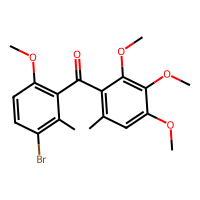

COc1cc(C)c(C(=O)c2c(OC)ccc(Br)c2C)c(OC)c1OC


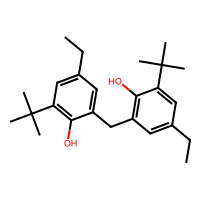

CCc1cc(Cc2cc(CC)cc(C(C)(C)C)c2O)c(O)c(C(C)(C)C)c1


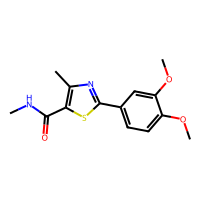

CNC(=O)c1sc(-c2ccc(OC)c(OC)c2)nc1C


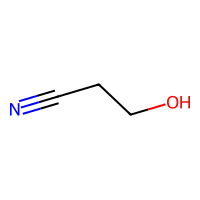

N#CCCO


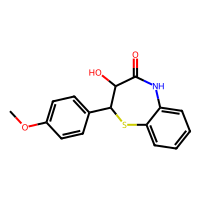

COc1ccc(C2Sc3ccccc3NC(=O)C2O)cc1


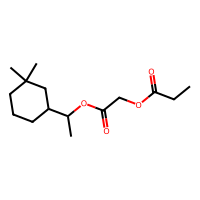

CCC(=O)OCC(=O)OC(C)C1CCCC(C)(C)C1


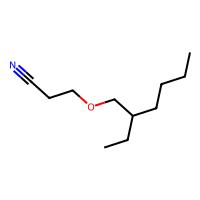

CCCCC(CC)COCCC#N


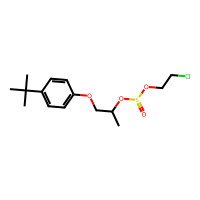

CC(COc1ccc(C(C)(C)C)cc1)OS(=O)OCCCl


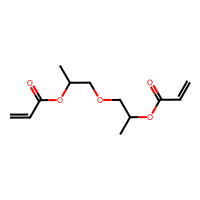

C=CC(=O)OC(C)COCC(C)OC(=O)C=C


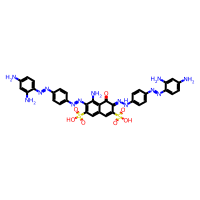

Nc1ccc(/N=N/c2ccc(/N=N/c3c(S(=O)(=O)O)cc4c(c3N)C(=O)/C(=N/Nc3ccc(/N=N/c5ccc(N)cc5N)cc3)C(S(=O)(=O)O)=C4)cc2)c(N)c1


In [9]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

def display_molecules_in_column(df, num_mols):
    for _, row in df.head(num_mols).iterrows():
        smi = row['SMILES']
        if smi is not None:
            mol = Chem.MolFromSmiles(smi)  # Create Mol object from SMILES
            if mol is not None:
                img = Draw.MolToImage(mol, size=(200, 200))
                display(img)
                print(smi)  # Prints the SMILES representation below the image

# Assuming 'df' is your DataFrame
# Display the first 10 molecules, each on a new row
display_molecules_in_column(moldf, 10)


Classes                          :  ['0' '1']
Number of cpds in each class     :  [2862 3689]
Total number of cpds             :  6551


{'0': 0, '1': 1}

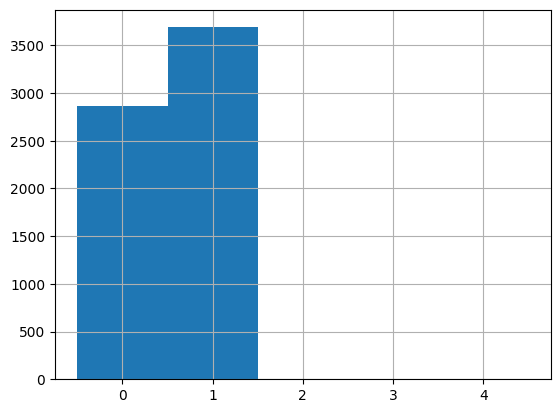

In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(moldf['Outcome']))
le.fit(list(set(outcomes)))
y = le.transform( moldf['Outcome'] )



print ("Classes                          : ",(outcomes))
print ("Number of cpds in each class     : ",np.unique([len(y[y==smi]) for smi in y]))
print ("Total number of cpds             : ",len(y))

S = moldf['Outcome']
info = {}
for i,cls in enumerate(S.unique()):
    info.update({cls:i})
    S = S.replace(cls,i)

#graph
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

In [11]:
x = x_data

#displaying x data
x_data

,LabuteASA,TPSA,AMW,NumLipinskiHBA,NumLipinskiHBD,NumRotatableBonds,NumHBD,NumHBA,NumAmideBonds,NumHeteroAtoms,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
2538,155.5263427500499,53.99000000000001,409.2760000000002,5,0,6,0,5,0,6,...,0.0,0.0,2.0,0.5,6.0,0.0,53.99000000000001,5.700439718141093,4.429,0.3157894736842105
1172,164.82121231710894,40.46,368.5610000000001,2,2,4,2,2,0,2,...,2.0,3.0,3.0,0.5,6.0,1.0,40.46,5.807354922057604,7.979000000000003,0.52
5916,121.11169389156761,60.45,292.36,5,1,4,1,5,1,6,...,1.0,0.0,0.0,0.25,0.0,0.0,26.02,4.700439718141093,2.312,1.0
1176,30.655948690287495,44.019999999999996,71.079,2,1,1,1,2,0,2,...,1.0,3.0,5.0,0.5,1.0,0.0,44.02,3.0,-0.848,0.6666666666666666
1153,126.68470792033817,58.56,301.367,4,2,2,2,4,1,5,...,2.0,0.0,2.0,0.4545454545454545,2.0,0.0,83.86,5.523561956057013,2.9620000000000006,0.1875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6093,162.4866030670798,80.23,379.4160000000001,5,1,2,1,5,2,7,...,0.0,0.0,3.0,0.5,5.0,1.0,88.28999999999999,5.523561956057013,7.569,0.0625
6092,116.30701665987984,71.95,297.40500000000003,5,1,3,1,5,0,7,...,2.0,7.0,7.0,0.4705882352941176,7.0,1.0,76.57000000000001,6.129283016944966,10.554000000000004,1.0
4937,157.9692677527407,123.17,419.3850000000001,7,2,6,2,7,2,13,...,0.0,0.0,5.0,0.5,2.0,0.0,33.36,4.0,-0.281,1.0
4939,55.04363954672381,23.550000000000004,154.125,1,0,2,0,1,0,5,...,1.0,3.0,4.0,0.4285714285714285,3.0,0.0,35.25,4.700439718141093,2.0729999999999995,0.4545454545454545


In [12]:
#Random Forest
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# parameter
paramgrid = {
    "n_estimators": [200,250],  
    "max_features": [
        int(np.sqrt(x.shape[1])),     
        int(x.shape[1] / 6)           
    ],
    "max_depth": [12,15,18],          
    "min_samples_leaf": [3,5],    
    "min_samples_split": [7,10]    
}

# Define the cross-validator as before
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

kappa_scorer = make_scorer(cohen_kappa_score)

model_rf_phys = GridSearchCV(estimator=RandomForestClassifier(class_weight='balanced'),
                     param_grid=paramgrid,
                     scoring=kappa_scorer,
                     cv=cv,
                     verbose=1,
                     n_jobs=-1) 

# Fit the model
model_rf_phys.fit(x, y)
best_model_rf_phys = model_rf_phys.best_estimator_


print("Best Params:", model_rf_phys.best_params_)
print("Best Score :", model_rf_phys.best_score_)


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Params: {'max_depth': 15, 'max_features': 9, 'min_samples_leaf': 5, 'min_samples_split': 7, 'n_estimators': 250}
Best Score : 0.3999565757358192


In [17]:
#Random Forest Evaluasi
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
import numpy as np

seed = 42
np.random.seed(seed)

X = np.array(x)
y = np.array(y)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []


def calculate_metrics(cm):
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ccr = (sensitivity + specificity) / 2

    return sensitivity, specificity, ppv, npv, ccr


for train_index, test_index in cv.split(X, y):

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    best_model_rf_phys.fit(X_train, y_train)

    y_pred = best_model_rf_phys.predict(X_test)
    y_proba = best_model_rf_phys.predict_proba(X_test)[:, 1]

    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)

    sensitivity, specificity, ppv, npv, ccr = calculate_metrics(cm)

    specificities.append(specificity)
    ppvs.append(ppv)
    npvs.append(npv)
    ccrs.append(ccr)


for i, cm in enumerate(confusion_matrices):
    print(f"\nConfusion Matrix Fold {i+1}")
    print(cm)


print(f"Overall CV Accuracy: {np.mean(accuracies)}")
print(f"Overall CV AUC: {np.mean(auc_scores)}")
print(f"Overall CV Precision: {np.mean(precisions)}")
print(f"Overall CV Recall (Sensitivity): {np.mean(recalls)}")
print(f"Overall CV F1 Score: {np.mean(f1_scores)}")
print(f"Overall CV Specificity: {np.mean(specificities)}")
print(f"Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}")
print(f"Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}")
print(f"Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}")


Confusion Matrix Fold 1
[[336 237]
 [160 578]]

Confusion Matrix Fold 2
[[368 205]
 [163 574]]

Confusion Matrix Fold 3
[[339 233]
 [170 568]]

Confusion Matrix Fold 4
[[368 204]
 [171 567]]

Confusion Matrix Fold 5
[[357 215]
 [164 574]]
Overall CV Accuracy: 0.706611117904286
Overall CV AUC: 0.7723689869911736
Overall CV Precision: 0.7236139792239984
Overall CV Recall (Sensitivity): 0.7755498192702415
Overall CV F1 Score: 0.7486110602655923
Overall CV Specificity: 0.6177522303176752
Overall CV PPV (Positive Predictive Value): 0.7236139792239984
Overall CV NPV (Negative Predictive Value): 0.6808859425386895
Overall CV CCR (Correct Classification Rate): 0.6966510247939584


In [13]:
# SVM 
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid 
paramgrid = {
     "C": [5,10,15],  # Regularization parameter
     "kernel": ['rbf'],  # Type of the kernel
     "gamma": ['scale', 'auto']  # Kernel coefficient
}

# 5-fold stratified shuffle split
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

# Cohen’s Kappa 
kappa_scorer = make_scorer(
    cohen_kappa_score,
    weights="quadratic"
)

# GridSearchCV
model_svm_phys = GridSearchCV(
    estimator=SVC(
        probability=True,
        class_weight="balanced",
        random_state=24
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    refit=True,
    verbose=1,
    n_jobs=-1
)

# Fit model
model_svm_phys.fit(x, y)

# Best model
best_model_svm_phys = model_svm_phys.best_estimator_

print("Best Params:", model_svm_phys.best_params_)
print("Best Score :", model_svm_phys.best_score_)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Params: {'C': 15, 'gamma': 'scale', 'kernel': 'rbf'}
Best Score : 0.15551769098002338


In [18]:
#SVM Evaluasi
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
import numpy as np

seed = 42
np.random.seed(seed)

X = np.array(x)
y = np.array(y)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []


def calculate_metrics(cm):
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ccr = (sensitivity + specificity) / 2

    return sensitivity, specificity, ppv, npv, ccr


for train_index, test_index in cv.split(X, y):

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    best_model_svm_phys.fit(X_train, y_train)

    y_pred = best_model_svm_phys.predict(X_test)
    y_proba = best_model_svm_phys.predict_proba(X_test)[:, 1]

    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)

    sensitivity, specificity, ppv, npv, ccr = calculate_metrics(cm)

    specificities.append(specificity)
    ppvs.append(ppv)
    npvs.append(npv)
    ccrs.append(ccr)


for i, cm in enumerate(confusion_matrices):
    print(f"\nConfusion Matrix Fold {i+1}")
    print(cm)


print(f"Overall CV Accuracy: {np.mean(accuracies)}")
print(f"Overall CV AUC: {np.mean(auc_scores)}")
print(f"Overall CV Precision: {np.mean(precisions)}")
print(f"Overall CV Recall (Sensitivity): {np.mean(recalls)}")
print(f"Overall CV F1 Score: {np.mean(f1_scores)}")
print(f"Overall CV Specificity: {np.mean(specificities)}")
print(f"Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}")
print(f"Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}")
print(f"Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}")



Confusion Matrix Fold 1
[[160 413]
 [112 626]]

Confusion Matrix Fold 2
[[182 391]
 [119 618]]

Confusion Matrix Fold 3
[[185 387]
 [133 605]]

Confusion Matrix Fold 4
[[192 380]
 [129 609]]

Confusion Matrix Fold 5
[[190 382]
 [157 581]]
Overall CV Accuracy: 0.6026565584222754
Overall CV AUC: 0.6095512738914537
Overall CV Precision: 0.6087931015252492
Overall CV Recall (Sensitivity): 0.8238044809213356
Overall CV F1 Score: 0.7000561629349826
Overall CV Specificity: 0.3176234760004394
Overall CV PPV (Positive Predictive Value): 0.6087931015252492
Overall CV NPV (Negative Predictive Value): 0.5840657473191609
Overall CV CCR (Correct Classification Rate): 0.5707139784608876


In [14]:
# XGB 
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Identify columns with object types
object_cols = x.select_dtypes(include=['object']).columns

# Convert object columns to numeric (if possible) or category
for col in object_cols:
    try:
        x[col] = pd.to_numeric(x[col])
    except ValueError:
        x[col] = x[col].astype('category')
        
paramgrid = {
    "max_depth": [5,7,10],          
    "n_estimators": [300,330],           
    "learning_rate": [0.2,0.4],   
    "subsample": [0.8],              
    "colsample_bytree": [0.8],  
    "reg_lambda": [2,4]            
}

# 5-fold stratified CV
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

# Cohen's Kappa 
kappa_scorer = make_scorer(cohen_kappa_score)

model_xgb_phys = GridSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=24,
        n_jobs=-1
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1
)

model_xgb_phys.fit(x, y)
best_model_xgb_phys = model_xgb_phys.best_estimator_

print("Best Params:", model_xgb_phys.best_params_)
print("Best Score :", model_xgb_phys.best_score_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 10, 'n_estimators': 300, 'reg_lambda': 2, 'subsample': 0.8}
Best Score : 0.3860299575026288


In [19]:
#XGB Evaluasi
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
import numpy as np

seed = 42
np.random.seed(seed)

X = np.array(x)
y = np.array(y)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []


def calculate_metrics(cm):
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ccr = (sensitivity + specificity) / 2

    return sensitivity, specificity, ppv, npv, ccr


for train_index, test_index in cv.split(X, y):

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    best_model_xgb_phys.fit(X_train, y_train)

    y_pred = best_model_xgb_phys.predict(X_test)
    y_proba = best_model_xgb_phys.predict_proba(X_test)[:, 1]

    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)

    sensitivity, specificity, ppv, npv, ccr = calculate_metrics(cm)

    specificities.append(specificity)
    ppvs.append(ppv)
    npvs.append(npv)
    ccrs.append(ccr)


for i, cm in enumerate(confusion_matrices):
    print(f"\nConfusion Matrix Fold {i+1}")
    print(cm)


print(f"Overall CV Accuracy: {np.mean(accuracies)}")
print(f"Overall CV AUC: {np.mean(auc_scores)}")
print(f"Overall CV Precision: {np.mean(precisions)}")
print(f"Overall CV Recall (Sensitivity): {np.mean(recalls)}")
print(f"Overall CV F1 Score: {np.mean(f1_scores)}")
print(f"Overall CV Specificity: {np.mean(specificities)}")
print(f"Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}")
print(f"Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}")
print(f"Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}")



Confusion Matrix Fold 1
[[343 230]
 [161 577]]

Confusion Matrix Fold 2
[[359 214]
 [152 585]]

Confusion Matrix Fold 3
[[350 222]
 [182 556]]

Confusion Matrix Fold 4
[[349 223]
 [160 578]]

Confusion Matrix Fold 5
[[349 223]
 [155 583]]
Overall CV Accuracy: 0.7066104191777154
Overall CV AUC: 0.7631290176304061
Overall CV Precision: 0.7213470063102179
Overall CV Recall (Sensitivity): 0.780431912867297
Overall CV F1 Score: 0.7496944000672185
Overall CV Specificity: 0.6114597444440376
Overall CV PPV (Positive Predictive Value): 0.7213470063102179
Overall CV NPV (Negative Predictive Value): 0.6838225588821567
Overall CV CCR (Correct Classification Rate): 0.6959458286556673


In [15]:
#Neural Network 
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid
paramgrid_nn = {
    "hidden_layer_sizes": [(600,900,1200),(256,512,1024)],  
    "activation": ['relu'],             
    "solver": ['adam'],              
    "alpha": [0.1,0.5,1]                          
}

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

model_nn_phys = GridSearchCV(
    estimator=MLPClassifier(max_iter=500, random_state=42),
    param_grid=paramgrid_nn,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1
)

# Fit the model
model_nn_phys.fit(x, y)
best_model_nn_phys = model_nn_phys.best_estimator_

print("Best Params:", model_nn_phys.best_params_)
print("Best Score :", model_nn_phys.best_score_)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Params: {'activation': 'relu', 'alpha': 0.5, 'hidden_layer_sizes': (600, 900, 1200), 'solver': 'adam'}
Best Score : 0.2499359773042075


In [20]:
#NN Evaluasi
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
import numpy as np

seed = 42
np.random.seed(seed)

X = np.array(x)
y = np.array(y)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []


def calculate_metrics(cm):
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ccr = (sensitivity + specificity) / 2

    return sensitivity, specificity, ppv, npv, ccr


for train_index, test_index in cv.split(X, y):

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    best_model_nn_phys.fit(X_train, y_train)

    y_pred = best_model_nn_phys.predict(X_test)
    y_proba = best_model_nn_phys.predict_proba(X_test)[:, 1]

    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)

    sensitivity, specificity, ppv, npv, ccr = calculate_metrics(cm)

    specificities.append(specificity)
    ppvs.append(ppv)
    npvs.append(npv)
    ccrs.append(ccr)


for i, cm in enumerate(confusion_matrices):
    print(f"\nConfusion Matrix Fold {i+1}")
    print(cm)


print(f"Overall CV Accuracy: {np.mean(accuracies)}")
print(f"Overall CV AUC: {np.mean(auc_scores)}")
print(f"Overall CV Precision: {np.mean(precisions)}")
print(f"Overall CV Recall (Sensitivity): {np.mean(recalls)}")
print(f"Overall CV F1 Score: {np.mean(f1_scores)}")
print(f"Overall CV Specificity: {np.mean(specificities)}")
print(f"Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}")
print(f"Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}")
print(f"Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}")



Confusion Matrix Fold 1
[[310 263]
 [200 538]]

Confusion Matrix Fold 2
[[249 324]
 [120 617]]

Confusion Matrix Fold 3
[[312 260]
 [220 518]]

Confusion Matrix Fold 4
[[324 248]
 [227 511]]

Confusion Matrix Fold 5
[[260 312]
 [207 531]]
Overall CV Accuracy: 0.6365424680187026
Overall CV AUC: 0.6807026831604335
Overall CV Precision: 0.6592606309022468
Overall CV Recall (Sensitivity): 0.7359992351619582
Overall CV F1 Score: 0.6944714750459439
Overall CV Specificity: 0.5084001513320885
Overall CV PPV (Positive Predictive Value): 0.6592606309022468
Overall CV NPV (Negative Predictive Value): 0.602774602246631
Overall CV CCR (Correct Classification Rate): 0.6221996932470233


In [22]:
# LGBM 
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid 
paramgrid = {
    "n_estimators": [350,400],
    "learning_rate": [0.1,0.2],
    "max_depth": [12],
    "min_child_samples": [20],
    "feature_fraction": [0.7],
    "bagging_fraction": [0.7],
    "bagging_freq": [1]
}

# Cross-validator 
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

# Scoring function
kappa_scorer = make_scorer(
    cohen_kappa_score,
    weights='quadratic'
)

# GridSearchCV
model_lgbm_phys = GridSearchCV(
    estimator=LGBMClassifier(
        objective="binary",
        class_weight="balanced",
        verbosity=-1,
        force_row_wise=True,
        random_state=24
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1
)

# fit model
model_lgbm_phys.fit(x, y)
best_model_lgbm_phys = model_lgbm_phys.best_estimator_

print("Best Params:", model_lgbm_phys.best_params_)
print("Best Score :", model_lgbm_phys.best_score_)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Params: {'bagging_fraction': 0.7, 'bagging_freq': 1, 'feature_fraction': 0.7, 'learning_rate': 0.1, 'max_depth': 12, 'min_child_samples': 20, 'n_estimators': 400}
Best Score : 0.37678473940133994


In [24]:
#LGBM Evaluasi
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
import numpy as np

seed = 42
np.random.seed(seed)

X = np.array(x)
y = np.array(y)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed
)

accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []


def calculate_metrics(cm):
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ccr = (sensitivity + specificity) / 2

    return sensitivity, specificity, ppv, npv, ccr


for train_index, test_index in cv.split(X, y):

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    best_model_lgbm_phys.fit(X_train, y_train)

    y_pred = best_model_lgbm_phys.predict(X_test)
    y_proba = best_model_lgbm_phys.predict_proba(X_test)[:, 1]

    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)

    sensitivity, specificity, ppv, npv, ccr = calculate_metrics(cm)

    specificities.append(specificity)
    ppvs.append(ppv)
    npvs.append(npv)
    ccrs.append(ccr)


for i, cm in enumerate(confusion_matrices):
    print(f"\nConfusion Matrix Fold {i+1}")
    print(cm)


print(f"Overall CV Accuracy: {np.mean(accuracies)}")
print(f"Overall CV AUC: {np.mean(auc_scores)}")
print(f"Overall CV Precision: {np.mean(precisions)}")
print(f"Overall CV Recall (Sensitivity): {np.mean(recalls)}")
print(f"Overall CV F1 Score: {np.mean(f1_scores)}")
print(f"Overall CV Specificity: {np.mean(specificities)}")
print(f"Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}")
print(f"Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}")
print(f"Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}")



Confusion Matrix Fold 1
[[362 211]
 [181 557]]

Confusion Matrix Fold 2
[[354 219]
 [168 569]]

Confusion Matrix Fold 3
[[364 208]
 [180 558]]

Confusion Matrix Fold 4
[[366 206]
 [177 561]]

Confusion Matrix Fold 5
[[370 202]
 [197 541]]
Overall CV Accuracy: 0.7024883982275636
Overall CV AUC: 0.7631554360991234
Overall CV Precision: 0.7270702984280912
Overall CV Recall (Sensitivity): 0.7552227774652238
Overall CV F1 Score: 0.7408122022404486
Overall CV Specificity: 0.6345281245804806
Overall CV PPV (Positive Predictive Value): 0.7270702984280912
Overall CV NPV (Negative Predictive Value): 0.6681071403321953
Overall CV CCR (Correct Classification Rate): 0.6948754510228522


In [23]:
import joblib

base_path = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Oral toxicity\model\physical chemical properties model"

joblib.dump(
    best_model_rf_phys,
    fr"{base_path}\Model_Oral_toxicity_RF_phys.pkl",
    compress=9
)

joblib.dump(
    best_model_svm_phys,
    fr"{base_path}\Model_Oral_toxicity_SVM_phys.pkl",
    compress=9
)

joblib.dump(
    best_model_xgb_phys,
    fr"{base_path}\Model_Oral_toxicity_XGB_phys.pkl",
    compress=9
)

joblib.dump(
    best_model_nn_phys,
    fr"{base_path}\Model_Oral_toxicity_NN_phys.pkl",
    compress=9
)

joblib.dump(
    best_model_lgbm_phys,
    fr"{base_path}\Model_Oral_toxicity_LGBM_phys.pkl",
    compress=9
)


['C:\\Users\\User\\Documents\\KULIAH TELKOM S1\\SKRIPSI\\UJI COBA QSAR - PRIBADI\\Oral toxicity\\model\\physical chemical properties model\\Model_Oral_toxicity_LGBM_phys.pkl']